# 下一章：DQN 入门

前面几章我们一直在用 `Q 表`：

- 状态不多时，直接用表格记录 `Q(state, action)` 很方便
- 但状态一多，Q 表就会变得很大，甚至根本存不下

这就是为什么我们要进入下一章：`DQN`，也就是 `Deep Q-Network`。

这一章你会学到：
- 为什么表格法不够用了
- 什么叫“用神经网络近似 Q 函数”
- DQN 的训练目标和 Q-learning 有什么关系


## 1. 先建立直觉

Q-learning 里我们学的是：

$Q(s, a)$

也就是“在状态 `s` 下做动作 `a` 有多好”。

以前我们是把它直接存成一张表：

- 行是状态
- 列是动作

但如果状态不是离散的小整数，而是：
- 一张图片
- 一串连续数值
- 很大的游戏画面

那就没法再用一张简单表格了。

DQN 的核心想法就是：

**不用 Q 表，改用一个神经网络来近似 `Q(s, a)`。**


## 2. 这一章的教学简化版

真实 DQN 通常会用：
- 深度神经网络
- 经验回放 `Replay Buffer`
- 目标网络 `Target Network`

但这一章我们先不把内容堆太满。

我们先做一个最小可运行版本：
- 环境还是简单的一维走格子
- 不再用 Q 表
- 改用一个小型神经网络输出两个动作的 Q 值

你可以把它理解为：

**Q-learning 的思想没变，只是把“表”换成了“网络”。**


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)
random.seed(42)
np.random.seed(42)


In [2]:
class LineWorld:
    def __init__(self, length=6):
        self.length = length
        self.goal = length - 1
        self.reset()

    def reset(self):
        self.position = 0
        return self.position

    def step(self, action):
        if action == 0:
            self.position = max(0, self.position - 1)
        else:
            self.position = min(self.goal, self.position + 1)

        reward = 1 if self.position == self.goal else -0.02
        done = self.position == self.goal
        return self.position, reward, done


## 3. 状态输入给网络要怎么表示

我们的状态本来只是位置编号，比如 `0, 1, 2, 3, 4, 5`。

为了让网络更容易学，我们把它做成 `one-hot` 向量：

- 状态 0 -> `[1, 0, 0, 0, 0, 0]`
- 状态 3 -> `[0, 0, 0, 1, 0, 0]`

然后网络输入这个向量，输出两个数：
- 第一个数表示向左的 Q 值
- 第二个数表示向右的 Q 值


In [3]:
def one_hot(state, n_states):
    x = np.zeros((n_states, 1))
    x[state, 0] = 1.0
    return x


class TinyQNetwork:
    """
    一个非常小的两层网络：
    state(one-hot) -> hidden(ReLU) -> Q values
    """

    def __init__(self, input_dim, hidden_dim, output_dim):
        self.W1 = np.random.randn(hidden_dim, input_dim) * 0.2
        self.b1 = np.zeros((hidden_dim, 1))
        self.W2 = np.random.randn(output_dim, hidden_dim) * 0.2
        self.b2 = np.zeros((output_dim, 1))

    def forward(self, x):
        z1 = self.W1 @ x + self.b1
        h = np.maximum(0, z1)
        q = self.W2 @ h + self.b2
        cache = (x, z1, h, q)
        return q, cache

    def predict(self, x):
        q, _ = self.forward(x)
        return q

    def train_step(self, x, target_q, lr=0.05):
        q, cache = self.forward(x)
        x, z1, h, _ = cache

        # 均方误差 loss = mean((q - target_q)^2)
        dq = 2.0 * (q - target_q) / q.shape[0]

        dW2 = dq @ h.T
        db2 = dq

        dh = self.W2.T @ dq
        dz1 = dh * (z1 > 0)

        dW1 = dz1 @ x.T
        db1 = dz1

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

        loss = float(np.mean((q - target_q) ** 2))
        return loss


## 4. DQN 的目标值从哪里来

这里最关键的一步，是目标值 `target`。

它其实和 Q-learning 一样：

$target = r + \gamma \max_{a'} Q(s', a')$

区别只是：
- 以前 `Q(s, a)` 在表格里
- 现在 `Q(s, a)` 是网络输出的

训练时我们会：
- 先让网络预测当前状态的两个 Q 值
- 复制一份作为目标 `target_q`
- 只修改“当前动作”那一个位置
- 然后让网络输出尽量逼近这个目标


In [4]:
env = LineWorld(length=6)
n_states = env.length
n_actions = 2

net = TinyQNetwork(input_dim=n_states, hidden_dim=12, output_dim=n_actions)

gamma = 0.9
epsilon = 0.3
episodes = 300
max_steps = 40
learning_rate = 0.05

episode_rewards = []
episode_steps = []
loss_history = []

for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        x = one_hot(state, n_states)
        q_values = net.predict(x)

        if random.random() < epsilon:
            action = random.randint(0, n_actions - 1)
        else:
            best_actions = np.flatnonzero(q_values.flatten() == np.max(q_values))
            action = int(random.choice(best_actions))

        next_state, reward, done = env.step(action)
        next_x = one_hot(next_state, n_states)
        next_q = net.predict(next_x)

        target_q = q_values.copy()
        target_value = reward if done else reward + gamma * float(np.max(next_q))
        target_q[action, 0] = target_value

        loss = net.train_step(x, target_q, lr=learning_rate)
        loss_history.append(loss)

        state = next_state
        total_reward += reward

        if done:
            episode_steps.append(step + 1)
            break
    else:
        episode_steps.append(max_steps)

    episode_rewards.append(total_reward)
    epsilon = max(0.02, epsilon * 0.995)

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 3))


训练完成。
最后 20 轮平均 reward: 0.911


In [5]:
print('各状态下网络预测的 Q 值：')
predicted_q_table = []
for s in range(n_states):
    q = net.predict(one_hot(s, n_states)).flatten()
    predicted_q_table.append(q)
    print(f'状态 {s}: left={q[0]:.3f}, right={q[1]:.3f}')

predicted_q_table = np.array(predicted_q_table)


各状态下网络预测的 Q 值：
状态 0: left=0.571, right=0.588
状态 1: left=0.522, right=0.676
状态 2: left=0.574, right=0.772
状态 3: left=0.593, right=0.880
状态 4: left=0.659, right=0.999
状态 5: left=0.437, right=0.683


In [6]:
action_map = {0: '←', 1: '→'}
policy = [action_map[int(np.argmax(predicted_q_table[s]))] for s in range(n_states - 1)] + ['G']

print('网络学到的策略：')
for s, a in enumerate(policy):
    print(f'状态 {s}: {a}')


网络学到的策略：
状态 0: →
状态 1: →
状态 2: →
状态 3: →
状态 4: →
状态 5: G


C:\Users\80740\AppData\Local\Temp\ipykernel_9416\360077882.py:18: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_9416\360077882.py:18: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_9416\360077882.py:18: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_9416\360077882.py:18: UserWarning: Glyph 22870 (\N{CJK UNIFIED IDEOGRAPH-5956}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_9416\360077882.py:18: UserWarning: Glyph 21169 (\N{CJK UNIFIED IDEOGRAPH-52B1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_9416\360077882.py:18: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing fro

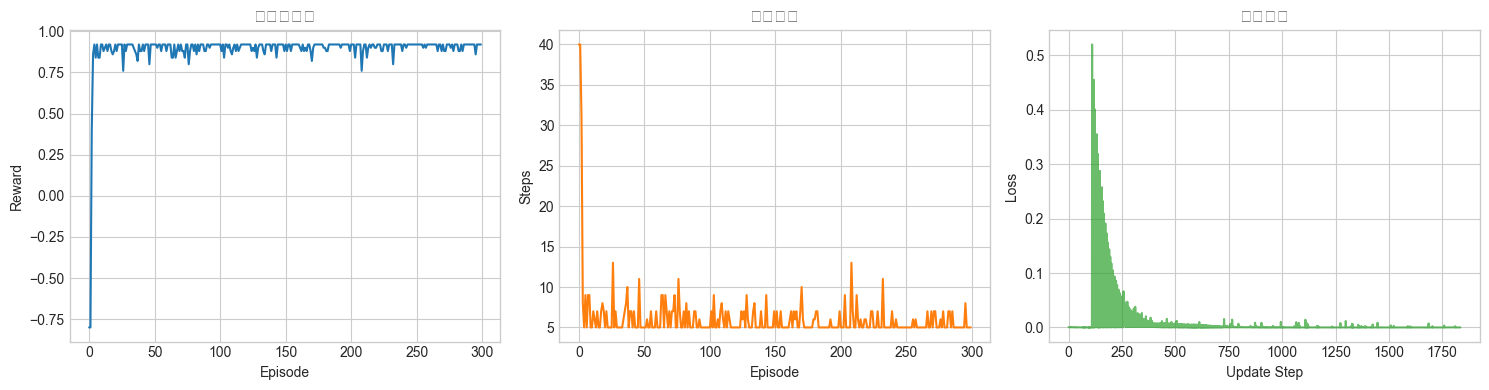

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_rewards, color='#1f77b4')
axes[0].set_title('每轮总奖励')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')

axes[1].plot(episode_steps, color='#ff7f0e')
axes[1].set_title('每轮步数')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')

axes[2].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[2].set_title('训练损失')
axes[2].set_xlabel('Update Step')
axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.show()


## 5. 这一章最重要的理解

你现在可以把 DQN 理解成这样：

- `Q-learning` 的目标公式没有变
- 变的是 `Q(s, a)` 的存储方式
- 从“查表”变成了“网络前向计算”

所以 DQN 不是推翻了 Q-learning，而是把 Q-learning 扩展到了更复杂的状态空间。


## 6. 这一章先别急着背的东西

真实 DQN 还会加入两个关键改进：

- `Replay Buffer`：把过去经验存起来，打乱后再训练
- `Target Network`：用一个较慢更新的目标网络，让训练更稳定

这两个东西就是下一章最自然的内容。

所以如果你学完这一章，下一章最适合接：
- `DQN + Replay Buffer`
- `Target Network` 是什么
- 为什么深度强化学习会比表格法更不稳定
